# Supervised Fill-Belief Adaptation and Market-Maker Competition

This notebook evaluates how supervised execution-belief adaptation changes market-maker calibration, profitability, and competitive quoting.

The workflow uses one fixed production configuration throughout:

- uniform-grid phantom labels and HJB candidates;
- exact FIFO queue-ahead features in live simulations;
- realized-time volatility features;
- the calibrated KGHM simulation dynamics;
- supervised binary cross-entropy updates only—no reward or policy-gradient learning.

Validated static-model, solo-adaptation, and independent-competition artifacts are reused from the completed run. Part 5 performs the remaining population-specific supervised adaptation and evaluation. Simulation outputs and compact report summaries are saved before figures are rendered, so plot styling can be revised without rerunning simulations.

In [ ]:
from __future__ import annotations

import shutil
import time
from collections import deque

import numpy as np
import pandas as pd
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

from research_core.classes.fill_belief_adaptation import (
    bce_score,
    run_population_adaptation_sim,
    update_fill_belief_nn,
)
from research_core.classes.fill_belief_diagnostics import (
    build_static_phantom_report_summaries,
)
from research_core.classes.helpers import resolve_data_path
from research_core.classes.mm_competition import run_competition_sim
from research_core.classes.mm_pipeline_analysis import (
    add_fill_probe_derived_columns,
    aggregate_adaptation_depth_calibration,
    aggregate_depth_calibration,
    aggregate_inventory_quote_depth,
    aggregate_quoted_depth_vs_n,
    build_run_level_metrics,
    load_competition_shards,
    paired_inventory_depth_difference,
    run_cluster_bootstrap_interval,
    save_analysis_summary,
)
from research_core.classes.mm_pipeline_plots import (
    plot_adaptation_pnl,
    plot_cross_stage_pnl,
    plot_cross_stage_quoted_depth,
    plot_depth_calibration,
    plot_depth_differences,
    plot_fill_by_intensity,
    plot_inventory_depth,
    plot_inventory_depth_comparison,
    plot_inventory_dispersion,
    plot_pnl_distributions,
    plot_quoted_depth_by_population,
    save_report_figure,
    set_report_style,
)

set_report_style()

In [ ]:
labels_dir = resolve_data_path("phantom_labels_sim_1M_size10000_uniform")
static_checkpoint = resolve_data_path(
    "phantom_models_sim_1M_size10000_uniform_logq/fillprob_mlp_best.pt"
)

solo_adaptation_dir = resolve_data_path("fill_belief_adaptation_solo_fifo")
solo_adapted_checkpoint = solo_adaptation_dir / "latest.pt"
independent_results_dir = resolve_data_path("mm_competition_supervised_independent")
report_cache_dir = resolve_data_path("simulation_fill_belief_report_cache")
figure_dir = resolve_data_path(".").parent / "figures" / "simulation_fill_belief"

# Reuse the completed population checkpoints, but isolate the new evaluation
# bank from earlier partial evaluations that used N-specific run-ID ranges.
population_run_tag = "eight_rounds_48x200k_unique_v1"
population_evaluation_tag = f"{population_run_tag}_paired_stage4_bank_v1"
population_model_root = resolve_data_path(
    f"fill_belief_adaptation_population_{population_run_tag}"
)
population_results_root = resolve_data_path(
    f"mm_competition_population_adapted_{population_evaluation_tag}"
)
population_training_report_cache_dir = report_cache_dir / f"part5_{population_run_tag}"
population_report_cache_dir = report_cache_dir / f"part5_{population_evaluation_tag}"
population_figure_dir = figure_dir / f"part5_{population_evaluation_tag}"
for output_dir in (
    report_cache_dir,
    figure_dir,
    population_training_report_cache_dir,
    population_report_cache_dir,
    population_figure_dir,
):
    output_dir.mkdir(parents=True, exist_ok=True)

# One fixed market and numerical configuration.
snapshot_kwargs = dict(
    asset="KGHM",
    day_key="d20170110",
    snapshot_time="10:00:00",
    tick_size=0.05,
)
ergodic_parameters = dict(
    k=16.01693035489198,
    vol_halflife=200,
    tick_size=0.05,
    intensity_A=0.05313567421660872,
)
order_size = 10_000
gamma = 0.1
drift_eps = 0.10
solver_tick = 0.025
max_delta = 2.0
resil_kappa = 0.0817
resil_tau_s = 4.5
resil_phi = 0.0746
resil_flow_tau_s = 32.3
n_workers = 12
base_seed = 20240604

competition_events = 200_000

# 240 agent outcomes per population.
population_evaluation_runs_by_n = {2: 120, 5: 48, 10: 24}
adaptation_events = 200_000
adaptation_rounds = 8

# Four-round sliding replay controls RAM and training time; earlier rounds remain
# represented through the warm-started network weights.
adaptation_replay_rounds = 4
adaptation_simulations_per_round = 48
adaptation_epochs = 8
adaptation_learning_rate = 1e-4
adaptation_batch_size = 65_536
adaptation_training_threads = 8
solo_adaptation_seed = 70_001
population_adaptation_seed = 80_001
population_counts = (1, 2, 5, 10)
population_adaptation_counts = (2, 5, 10)

# Run the slowest population first
population_adaptation_run_order = (10, 5, 2)
bootstrap_samples = 2_000
seed_multiplier = 999_983
seed_modulus = 2**32


def simulation_count(n_agents):
    """Use the same number of independent market paths for every population."""
    assert int(n_agents) in population_adaptation_counts
    return adaptation_simulations_per_round


def worker_seed(base, worker_run_id):
    """Mirror init_worker_seed so seed manifests can be audited before running."""
    return (int(base) + int(worker_run_id) * seed_multiplier) % seed_modulus


def population_training_run_id(n_agents, adaptation_step, local_run_id):
    """Return a globally unique worker run ID for one adaptation simulation."""
    population_index = population_adaptation_counts.index(int(n_agents))
    return (
        (population_index * adaptation_rounds + int(adaptation_step))
        * adaptation_simulations_per_round
        + int(local_run_id)
    )


def population_evaluation_run_ids(n_agents):
    """Reuse every completed Stage-4 scenario ID for this population."""
    n_agents = int(n_agents)
    assert n_agents in population_evaluation_runs_by_n
    return range(population_evaluation_runs_by_n[n_agents])


common_simulation_kwargs = dict(
    snapshot_kwargs=snapshot_kwargs,
    erg_params=ergodic_parameters,
    size=order_size,
    gamma=gamma,
    solver_tick=solver_tick,
    max_delta=max_delta,
    poisson_tau=1.0,
    delta_lo=0.0,
    max_iter=1_000,
    tol=1e-3,
    drift_eps=drift_eps,
    requote_cadence=1.0,
    base_seed=base_seed,
    day_span_s=None,
    vol_feature_mode="realized_time",
    agents_affect_kernels=False,
    agents_affect_mo_sizing=False,
    rho_in=0.3,
    solver_engine="hull",
    candidate_grid="uniform",
    queue_ahead_mode="exact_fifo",
    resil_kappa=resil_kappa,
    resil_tau=resil_tau_s,
    resil_varphi=resil_phi,
    resil_tau_f=resil_flow_tau_s,
    verbose=False,
)

assert labels_dir.is_dir(), f"Missing validated phantom labels: {labels_dir}"
assert static_checkpoint.is_file(), f"Missing validated static checkpoint: {static_checkpoint}"
assert solo_adapted_checkpoint.is_file(), (
    f"Missing completed solo-adaptation checkpoint: {solo_adapted_checkpoint}"
)
print(f"Solo-adapted checkpoint: {solo_adapted_checkpoint}")

Solo-adapted checkpoint: C:\Users\jaspe\Documents\CLS\Thesis\test_thesis\thesis\data\fill_belief_adaptation_solo_fifo\latest.pt


## 1–2. Static Fill-Belief Model

The static neural network was trained previously on uniform-grid phantom orders generated from the 60 calibrated simulations. This section does not regenerate labels or retrain the model. It evaluates the fixed checkpoint on held-out simulation days and compares it with a depth-only exponential benchmark.

Opposite-side market-order intensity is the relevant execution signal: sell-market-order intensity for bid quotes and buy-market-order intensity for ask quotes. Uncertainty is clustered by simulation day rather than by individual phantom observations.

In [3]:
static_cache_dir = report_cache_dir / "static_phantom_model"
static_report_paths = {
    "predictions": static_cache_dir / "test_predictions.parquet",
    "fill_vs_opposite_intensity": static_cache_dir / "fill_vs_opposite_intensity.parquet",
    "reliability_by_intensity_tercile": static_cache_dir / "reliability_by_intensity_tercile.parquet",
    "fill_vs_delta_by_intensity_tercile": static_cache_dir / "fill_vs_delta_by_intensity_tercile.parquet",
}
if not all(path.is_file() for path in static_report_paths.values()):
    static_report_paths = build_static_phantom_report_summaries(
        ckpt_path=static_checkpoint,
        cache_dir=static_cache_dir,
    )
else:
    print("Reusing cached static-model diagnostics.")

static_fill_by_intensity = pd.read_parquet(
    static_report_paths["fill_vs_opposite_intensity"]
)
static_reliability = pd.read_parquet(
    static_report_paths["reliability_by_intensity_tercile"]
)
static_fill_by_depth = pd.read_parquet(
    static_report_paths["fill_vs_delta_by_intensity_tercile"]
)
cached_test_days = pd.read_parquet(
    static_report_paths["predictions"], columns=["day"]
)["day"].nunique()
print(f"Static diagnostics cached from {cached_test_days} held-out days.")

Reusing cached static-model diagnostics.
Static diagnostics cached from 6 held-out days.


WindowsPath('C:/Users/jaspe/Documents/CLS/Thesis/test_thesis/thesis/figures/simulation_fill_belief/part1_fill_vs_opposite_mo_intensity.pdf')

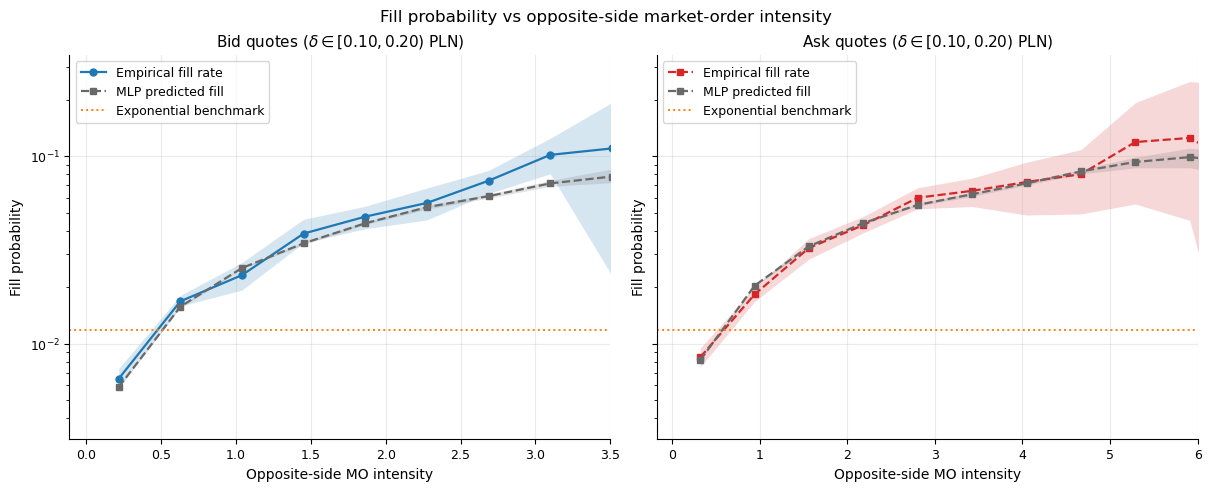

In [4]:
fig = plot_fill_by_intensity(static_fill_by_intensity)
save_report_figure(fig, figure_dir / "part1_fill_vs_opposite_mo_intensity.pdf")

## 3. Supervised Adaptation to Exact FIFO Execution

The phantom-trained network begins with placement-time queue semantics. Eight completed rounds of live single-agent simulations supplied exact-FIFO fill/no-fill observations. After each round, the same network was warm-started and fitted by binary cross-entropy on the four most recent rounds.

The saved final checkpoint was evaluated on separate random seeds. This section loads those completed results and regenerates the realized-PnL trajectory without rerunning a simulation.

In [5]:
adaptation_metrics = pd.read_parquet(
    report_cache_dir / "solo_adaptation_metrics.parquet"
)
adaptation_depth = pd.read_parquet(
    report_cache_dir / "solo_adaptation_depth.parquet"
)
# Simulator MTM is stored in tick-index units; convert once to PLN (tick_size=0.05).
adaptation_metrics["realized_pnl"] = (
    adaptation_metrics["realized_pnl"] * float(snapshot_kwargs["tick_size"])
)
heldout_pnl = adaptation_metrics.loc[
    adaptation_metrics["stage"] == "Final held-out", "realized_pnl"
]
print(
    f"Loaded completed solo adaptation: mean held-out PnL "
    f"{heldout_pnl.mean():,.0f} PLN; "
    f"profitable runs {(heldout_pnl > 0).mean():.0%}."
)

Loaded completed solo adaptation: mean held-out PnL 35,197 PLN; profitable runs 83%.


In [6]:
adaptation_depth_summary = aggregate_adaptation_depth_calibration(
    adaptation_depth,
    n_bootstrap=bootstrap_samples,
    bootstrap_seed=solo_adaptation_seed,
)
adaptation_depth_summary.to_parquet(
    report_cache_dir / "solo_adaptation_depth_summary.parquet", index=False
)

WindowsPath('C:/Users/jaspe/Documents/CLS/Thesis/test_thesis/thesis/figures/simulation_fill_belief/part3_realized_pnl_during_adaptation.pdf')

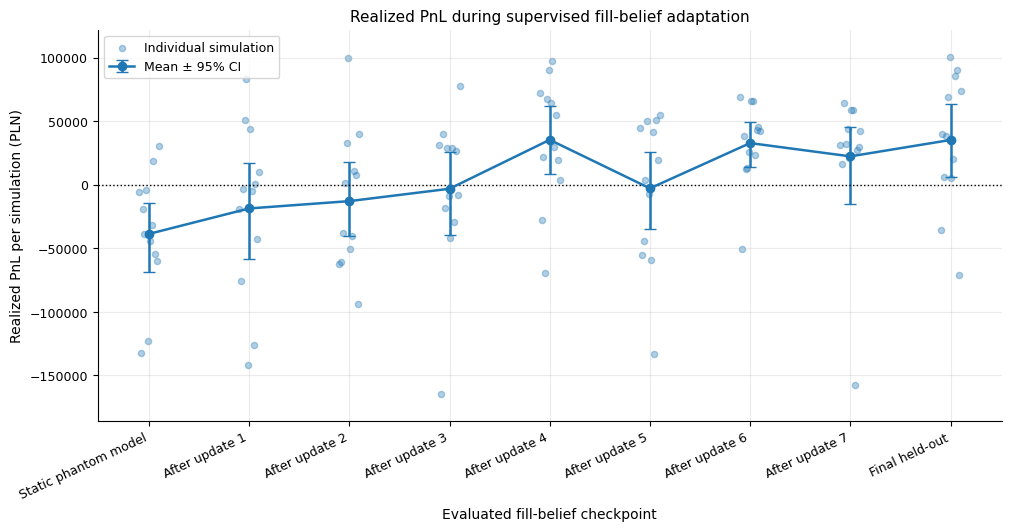

In [7]:
fig = plot_adaptation_pnl(adaptation_metrics)
save_report_figure(fig, figure_dir / "part3_realized_pnl_during_adaptation.pdf")

## 4. Independent Multi-Agent Competition

The final solo-adapted fill-belief network is deployed without further fitting. Each market maker independently optimizes its own HJB objective while interacting through the shared order book.

The completed benchmark covers populations of 1, 2, 5, and 10 market makers. This section loads the saved raw shards and recomputes only compact report summaries and figures.

In [8]:
independent_summary_paths = [
    independent_results_dir / f"setup_{n_agents:02d}" / "summary.parquet"
    for n_agents in population_counts
]
missing_independent_summaries = [
    path for path in independent_summary_paths if not path.is_file()
]
assert not missing_independent_summaries, (
    f"Missing completed independent-competition summaries: "
    f"{missing_independent_summaries}"
)
print("Loaded completed independent benchmark for N = 1, 2, 5, and 10.")

Loaded completed independent benchmark for N = 1, 2, 5, and 10.


In [9]:
independent_logs = load_competition_shards(independent_results_dir)
independent_fill = add_fill_probe_derived_columns(independent_logs["fill_probe"])
independent_run_metrics = build_run_level_metrics(
    independent_fill,
    independent_logs["summary"],
    tick_size=float(snapshot_kwargs["tick_size"]),
)

inventory_limit = float(independent_fill["inventory"].abs().quantile(0.99))
inventory_bin_edges = np.linspace(-inventory_limit, inventory_limit, 16)
independent_depth = aggregate_quoted_depth_vs_n(
    independent_fill,
    n_bootstrap=bootstrap_samples,
    bootstrap_seed=base_seed,
)
independent_calibration = aggregate_depth_calibration(
    independent_fill,
    n_bootstrap=bootstrap_samples,
    bootstrap_seed=base_seed,
)
independent_inventory_depth = aggregate_inventory_quote_depth(
    independent_fill,
    inventory_bin_edges,
    n_bootstrap=bootstrap_samples,
    bootstrap_seed=base_seed,
)


def summarize_inventory_dispersion(state_frame):
    """Return one mean absolute-inventory observation per agent and run."""
    frame = state_frame.assign(abs_inventory=state_frame["inventory"].abs())
    return (
        frame.groupby(["n_agents", "run_id", "agent_id"], as_index=False)
        .agg(abs_inventory=("abs_inventory", "mean"))
    )


independent_inventory_dispersion = summarize_inventory_dispersion(
    independent_logs["state"]
)
part4_tables = {
    "independent_depth": independent_depth,
    "independent_calibration": independent_calibration,
    "independent_run_metrics": independent_run_metrics,
    "independent_inventory_dispersion": independent_inventory_dispersion,
    "independent_inventory_depth": independent_inventory_depth,
}
save_analysis_summary(part4_tables, report_cache_dir / "part4")

WindowsPath('C:/Users/jaspe/Documents/CLS/Thesis/test_thesis/thesis/figures/simulation_fill_belief/part4_independent_quoted_depth.pdf')

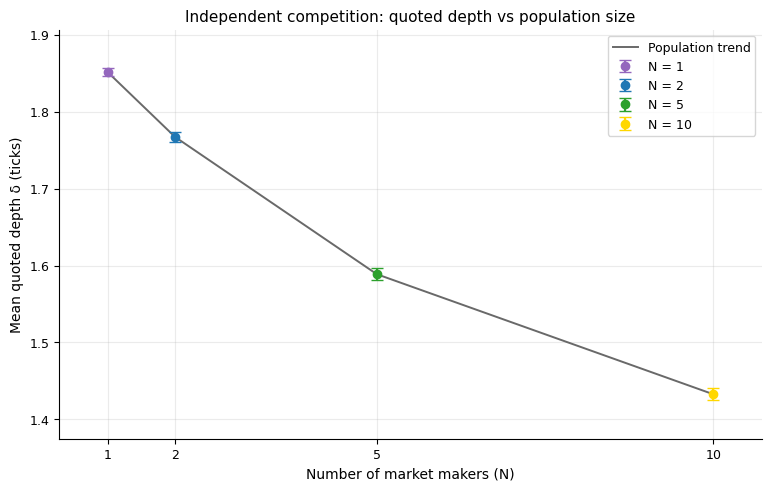

In [10]:
fig = plot_quoted_depth_by_population(
    independent_depth,
    title="Independent competition: quoted depth vs population size",
)
save_report_figure(fig, figure_dir / "part4_independent_quoted_depth.pdf")

WindowsPath('C:/Users/jaspe/Documents/CLS/Thesis/test_thesis/thesis/figures/simulation_fill_belief/part4_independent_fill_calibration.pdf')

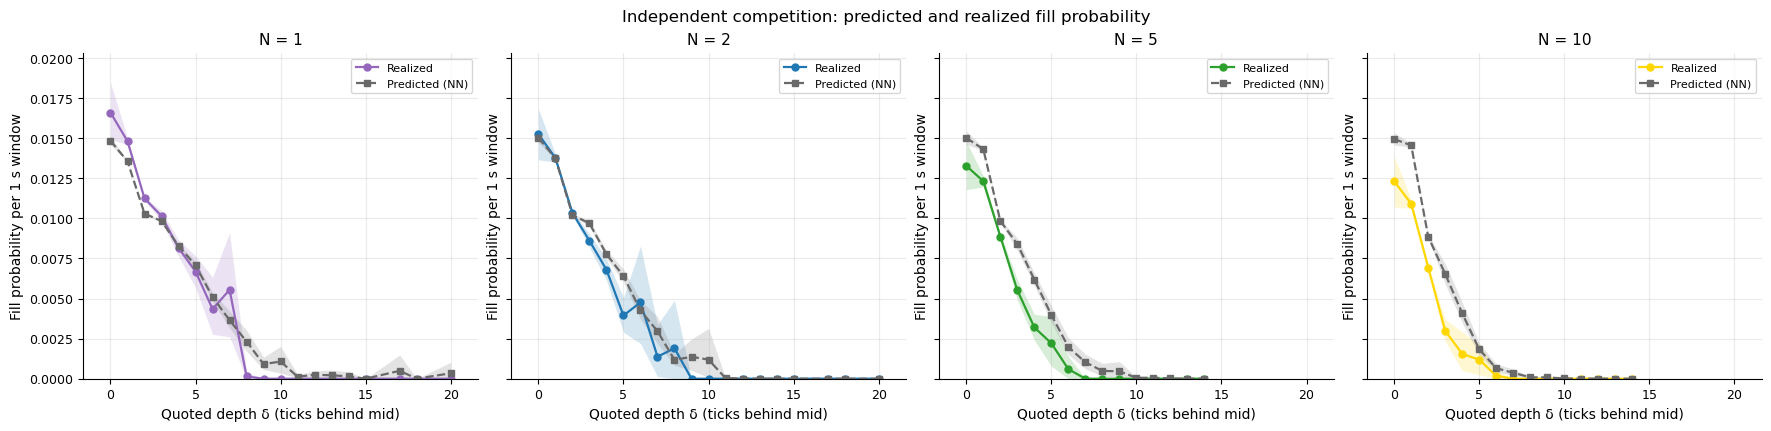

In [11]:
fig = plot_depth_calibration(
    independent_calibration,
    title="Independent competition: predicted and realized fill probability",
)
save_report_figure(fig, figure_dir / "part4_independent_fill_calibration.pdf")

WindowsPath('C:/Users/jaspe/Documents/CLS/Thesis/test_thesis/thesis/figures/simulation_fill_belief/part4_independent_pnl.pdf')

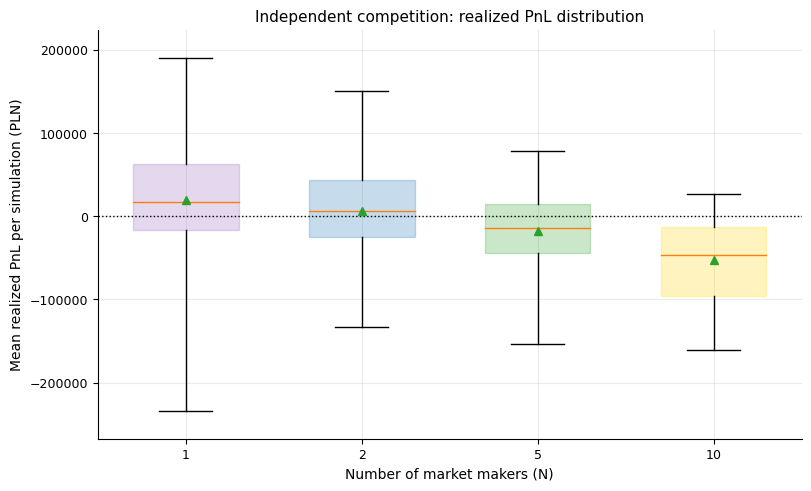

In [12]:
fig = plot_pnl_distributions(
    independent_run_metrics,
    title="Independent competition: realized PnL distribution",
)
save_report_figure(fig, figure_dir / "part4_independent_pnl.pdf")

WindowsPath('C:/Users/jaspe/Documents/CLS/Thesis/test_thesis/thesis/figures/simulation_fill_belief/part4_independent_inventory_dispersion.pdf')

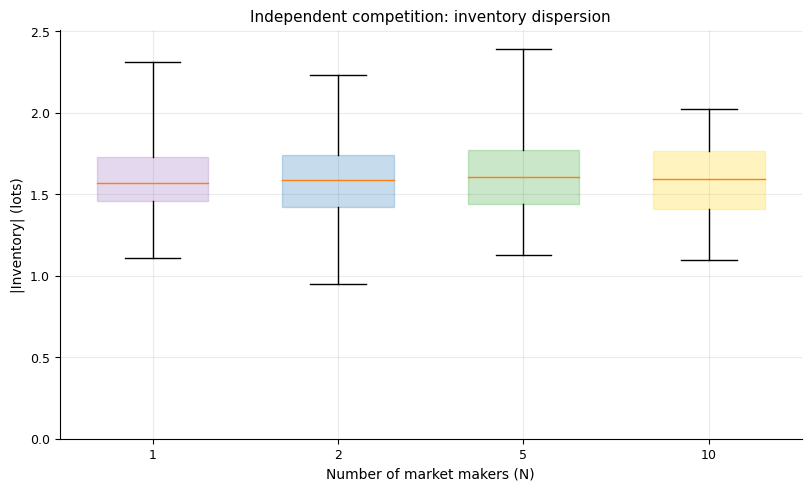

In [13]:
fig = plot_inventory_dispersion(
    independent_inventory_dispersion,
    title="Independent competition: inventory dispersion",
    lot_size=order_size,
)
save_report_figure(fig, figure_dir / "part4_independent_inventory_dispersion.pdf")

WindowsPath('C:/Users/jaspe/Documents/CLS/Thesis/test_thesis/thesis/figures/simulation_fill_belief/part4_independent_depth_vs_inventory.pdf')

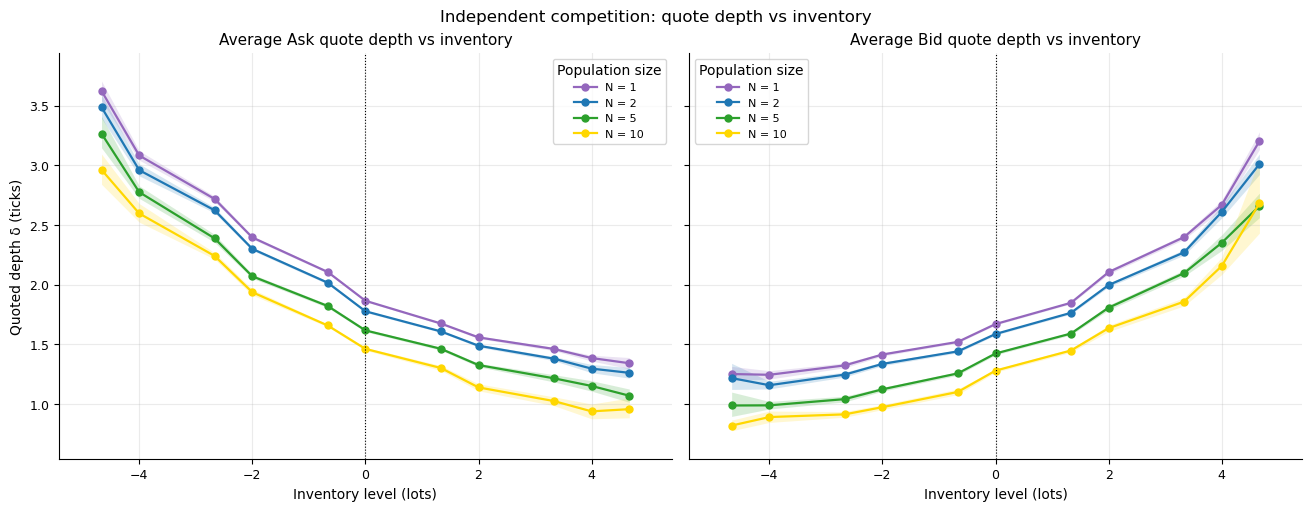

In [14]:
fig = plot_inventory_depth(
    independent_inventory_depth,
    title="Independent competition: quote depth vs inventory",
    lot_size=order_size,
)
save_report_figure(fig, figure_dir / "part4_independent_depth_vs_inventory.pdf")

## 5. Population-Specific Supervised Adaptation

One shared fill-belief network is fitted separately inside populations of 2, 5, and 10 competing market makers. Every population restarts from the validated final solo-adapted checkpoint and receives eight population-specific supervised updates. Each update uses 48 newly seeded simulations of 200,000 events, so every N is trained on 384 distinct market paths.

A four-round sliding replay window limits memory and training time. Earlier rounds still affect later checkpoints through warm-started weights, while each update trains directly on the four most recent batches. The slowest N=10 pipeline runs first, and each completed round is saved for deterministic resumption.

Evaluation reuses every completed Stage-4 solo-adapted scenario: 120 runs for N=2, 48 for N=5, and 24 for N=10 (240 agent outcomes per population). Each population-adapted policy is evaluated on the corresponding run IDs, yielding paired comparisons without rerunning the solo policy. Evaluation seeds remain disjoint from all adaptation seeds. New population-evaluation outputs, caches, and figures use a separate versioned namespace; existing Stage 1–4 artifacts remain read-only.

In [15]:
population_checkpoints = {}
population_metrics_path = (
    population_training_report_cache_dir / "population_adaptation_metrics.parquet"
)
population_seed_manifest_path = (
    population_training_report_cache_dir / "population_adaptation_seed_manifest.parquet"
)

adaptation_seed_manifest = pd.DataFrame(
    [
        {
            "phase": "population_adaptation",
            "n_agents": n_agents,
            "adaptation_step": adaptation_step,
            "local_run_id": local_run_id,
            "worker_run_id": population_training_run_id(
                n_agents, adaptation_step, local_run_id
            ),
            "seed": worker_seed(
                population_adaptation_seed,
                population_training_run_id(n_agents, adaptation_step, local_run_id),
            ),
            "n_events": adaptation_events,
        }
        for n_agents in population_adaptation_counts
        for adaptation_step in range(adaptation_rounds)
        for local_run_id in range(adaptation_simulations_per_round)
    ]
)
assert len(adaptation_seed_manifest) == (
    len(population_adaptation_counts)
    * adaptation_rounds
    * adaptation_simulations_per_round
)
assert adaptation_seed_manifest["worker_run_id"].is_unique
assert adaptation_seed_manifest["seed"].is_unique
preview_evaluation_seeds = {
    worker_seed(base_seed, run_id)
    for n_agents in population_adaptation_counts
    for run_id in population_evaluation_run_ids(n_agents)
}
assert set(adaptation_seed_manifest["seed"]).isdisjoint(preview_evaluation_seeds)
adaptation_seed_manifest.to_parquet(population_seed_manifest_path, index=False)

if population_metrics_path.is_file():
    saved_population_training = pd.read_parquet(population_metrics_path)
    population_training_rows = saved_population_training.loc[
        saved_population_training["adaptation_step"] < adaptation_rounds
    ].to_dict("records")
else:
    population_training_rows = []
population_simulation_kwargs = {
    **common_simulation_kwargs,
    "T": adaptation_events,
    "base_seed": population_adaptation_seed,
}

for n_agents in population_adaptation_run_order:
    model_dir = population_model_root / f"N_{n_agents:02d}"
    model_dir.mkdir(parents=True, exist_ok=True)
    latest_checkpoint = model_dir / "latest.pt"
    target_checkpoint = model_dir / f"round_{adaptation_rounds - 1:02d}.pt"
    if target_checkpoint.is_file():
        population_checkpoints[n_agents] = target_checkpoint
        print(
            f"Reusing eight-round population adaptation for N={n_agents} "
            f"({target_checkpoint.name})."
        )
        continue

    round_checkpoints = sorted(model_dir.glob("round_*.pt"))
    start_step = len(round_checkpoints)
    expected_round_names = [f"round_{step:02d}.pt" for step in range(start_step)]
    assert [path.name for path in round_checkpoints] == expected_round_names, (
        f"Non-contiguous adaptation checkpoints under {model_dir}"
    )
    population_training_rows = [
        row
        for row in population_training_rows
        if row["n_agents"] != n_agents or row["adaptation_step"] < start_step
    ]

    replay = deque(maxlen=adaptation_replay_rounds)
    replay_start_step = max(0, start_step - adaptation_replay_rounds)
    for completed_step in range(replay_start_step, start_step):
        features_path = model_dir / f"features_round_{completed_step:02d}.npy"
        labels_path = model_dir / f"labels_round_{completed_step:02d}.npy"
        assert features_path.is_file() and labels_path.is_file(), (
            f"Missing saved replay arrays for N={n_agents}, step={completed_step}"
        )
        replay.append((np.load(features_path), np.load(labels_path)))

    if start_step == 0:
        current_checkpoint = solo_adapted_checkpoint
    else:
        current_checkpoint = model_dir / f"round_{start_step - 1:02d}.pt"
        print(f"Resuming N={n_agents} from update {start_step + 1}/{adaptation_rounds}.")
    n_simulations = simulation_count(n_agents)

    for adaptation_step in range(start_step, adaptation_rounds):
        round_started_at = time.time()
        round_run_ids = [
            population_training_run_id(n_agents, adaptation_step, local_run_id)
            for local_run_id in range(n_simulations)
        ]
        assert len(round_run_ids) == len(set(round_run_ids)) == n_simulations
        simulation_results = Parallel(n_jobs=min(n_workers, n_simulations))(
            delayed(run_population_adaptation_sim)(
                worker_run_id,
                n_agents,
                ckpt_path=str(current_checkpoint),
                **population_simulation_kwargs,
            )
            for worker_run_id in round_run_ids
        )
        simulation_seconds = time.time() - round_started_at
        observed_seeds = {run["seed"] for run in simulation_results}
        expected_seeds = {
            worker_seed(population_adaptation_seed, run_id)
            for run_id in round_run_ids
        }
        assert observed_seeds == expected_seeds

        step_features = np.vstack([run["X"] for run in simulation_results])
        step_labels = np.concatenate([run["y"] for run in simulation_results])
        step_predictions = np.concatenate([run["pred"] for run in simulation_results])
        np.save(
            model_dir / f"features_round_{adaptation_step:02d}.npy",
            step_features,
            allow_pickle=False,
        )
        np.save(
            model_dir / f"labels_round_{adaptation_step:02d}.npy",
            step_labels,
            allow_pickle=False,
        )
        replay.append((step_features, step_labels))
        replay_features = np.vstack([batch[0] for batch in replay])
        replay_labels = np.concatenate([batch[1] for batch in replay])

        round_checkpoint = model_dir / f"round_{adaptation_step:02d}.pt"
        training_seed = worker_seed(population_adaptation_seed, round_run_ids[0])
        try:
            update_info = update_fill_belief_nn(
                str(current_checkpoint),
                replay_features,
                replay_labels,
                out_path=str(round_checkpoint),
                epochs=adaptation_epochs,
                lr=adaptation_learning_rate,
                batch_size=adaptation_batch_size,
                seed=training_seed,
                verbose=False,
                training_num_threads=adaptation_training_threads,
            )
        except RuntimeError:
            round_checkpoint.unlink(missing_ok=True)
            print("Multithreaded training failed; retrying this update on one thread.")
            update_info = update_fill_belief_nn(
                str(current_checkpoint),
                replay_features,
                replay_labels,
                out_path=str(round_checkpoint),
                epochs=adaptation_epochs,
                lr=adaptation_learning_rate,
                batch_size=adaptation_batch_size,
                seed=training_seed,
                verbose=False,
                training_num_threads=1,
            )
        shutil.copyfile(round_checkpoint, latest_checkpoint)
        current_checkpoint = latest_checkpoint
        population_training_rows.append(
            {
                "n_agents": n_agents,
                "adaptation_step": adaptation_step,
                "n_simulations": n_simulations,
                "n_events": adaptation_events,
                "n_unique_seeds": len(observed_seeds),
                "n_observations": len(step_labels),
                "predicted_fill": float(step_predictions.mean()),
                "realized_fill": float(step_labels.mean()),
                "bce_before_update": bce_score(step_predictions, step_labels),
                "training_loss_first": update_info["loss_first"],
                "training_loss_last": update_info["loss_last"],
                "simulation_seconds": simulation_seconds,
                "training_seconds": update_info["training_seconds"],
                "training_num_threads": update_info["training_num_threads"],
            }
        )
        population_training = (
            pd.DataFrame(population_training_rows)
            .sort_values(["n_agents", "adaptation_step"])
            .reset_index(drop=True)
        )
        population_training.to_parquet(population_metrics_path, index=False)
        total_minutes = (time.time() - round_started_at) / 60
        print(
            f"Population N={n_agents}, update {adaptation_step + 1}/{adaptation_rounds}: "
            f"48 unique simulations; predicted/realized fill "
            f"{step_predictions.mean():.4f}/{step_labels.mean():.4f}; "
            f"simulation {simulation_seconds / 60:.1f} min; "
            f"training {update_info['training_seconds'] / 60:.1f} min "
            f"({update_info['training_num_threads']} threads); "
            f"total {total_minutes:.1f} min"
        )
        del simulation_results, step_predictions, replay_features, replay_labels

    population_checkpoints[n_agents] = target_checkpoint

population_training = (
    pd.DataFrame(population_training_rows)
    .sort_values(["n_agents", "adaptation_step"])
    .reset_index(drop=True)
)
population_training.to_parquet(population_metrics_path, index=False)

Reusing eight-round population adaptation for N=10 (round_07.pt).
Reusing eight-round population adaptation for N=5 (round_07.pt).
Reusing eight-round population adaptation for N=2 (round_07.pt).


In [16]:
population_checkpoints = {
    n_agents: population_model_root
    / f"N_{n_agents:02d}"
    / f"round_{adaptation_rounds - 1:02d}.pt"
    for n_agents in population_adaptation_counts
}
assert all(path.is_file() for path in population_checkpoints.values()), (
    f"Missing population-adapted checkpoints: {population_checkpoints}"
)

evaluation_run_ids_by_n = {
    n_agents: set(population_evaluation_run_ids(n_agents))
    for n_agents in population_adaptation_counts
}
evaluation_seed_manifest = pd.DataFrame(
    [
        {
            "phase": "paired_policy_evaluation",
            "n_agents": n_agents,
            "scenario_id": scenario_id,
            "worker_run_id": worker_run_id,
            "seed": worker_seed(base_seed, worker_run_id),
            "n_events": competition_events,
            "paired_conditions": "solo_adapted,population_adapted",
        }
        for n_agents in population_adaptation_counts
        for scenario_id, worker_run_id in enumerate(
            population_evaluation_run_ids(n_agents)
        )
    ]
)
assert len(evaluation_seed_manifest) == sum(population_evaluation_runs_by_n.values())
assert not evaluation_seed_manifest.duplicated(
    ["n_agents", "worker_run_id"]
).any()
observed_evaluation_counts = (
    evaluation_seed_manifest.groupby("n_agents")["worker_run_id"].nunique().to_dict()
)
assert observed_evaluation_counts == population_evaluation_runs_by_n
assert set(evaluation_seed_manifest["seed"]).isdisjoint(
    set(adaptation_seed_manifest["seed"])
)
evaluation_seed_manifest.to_parquet(
    population_report_cache_dir / "paired_evaluation_seed_manifest.parquet",
    index=False,
)


def append_evaluation_results(summary, simulation_results):
    """Append worker summaries while retaining the auditable scenario seed."""
    new_rows = [
        {**row, "seed": int(simulation["seed"])}
        for simulation in simulation_results
        for row in simulation["summary"]
    ]
    if not new_rows:
        return summary
    return (
        pd.concat([summary, pd.DataFrame(new_rows)], ignore_index=True)
        .drop_duplicates(["run_id", "agent_id"], keep="last")
        .sort_values(["run_id", "agent_id"])
        .reset_index(drop=True)
    )


evaluation_summaries = {"population_adapted": {}, "solo_adapted": {}}
condition_labels = {
    "population_adapted": "Population-adapted",
    "solo_adapted": "Solo-adapted benchmark",
}

# Work from N=10 downward and save each population-adapted condition
# immediately. Every solo benchmark is reused read-only from Stage 4.
for n_agents in population_adaptation_run_order:
    solo_output_dir = independent_results_dir
    condition_specs = {
        "population_adapted": {
            "checkpoint": population_checkpoints[n_agents],
            "output_dir": population_results_root / f"N_{n_agents:02d}",
        },
        "solo_adapted": {
            "checkpoint": solo_adapted_checkpoint,
            "output_dir": solo_output_dir,
        },
    }
    target_run_ids = evaluation_run_ids_by_n[n_agents]
    target_evaluation_runs = population_evaluation_runs_by_n[n_agents]
    assert len(target_run_ids) == target_evaluation_runs

    for condition, spec in condition_specs.items():
        output_dir = spec["output_dir"]
        setup_dir = output_dir / f"setup_{n_agents:02d}"
        if condition == "population_adapted":
            setup_dir.mkdir(parents=True, exist_ok=True)
        summary_path = setup_dir / "summary.parquet"
        if summary_path.is_file():
            summary = pd.read_parquet(summary_path)
            completed_run_ids = set(summary["run_id"].unique())
        else:
            summary = pd.DataFrame()
            completed_run_ids = set()

        pending_run_ids = sorted(target_run_ids - completed_run_ids)
        if condition == "solo_adapted":
            assert not pending_run_ids, (
                f"The preserved Stage-4 N={n_agents} benchmark has only "
                f"{target_evaluation_runs - len(pending_run_ids)}/"
                f"{target_evaluation_runs} required scenarios; refusing to modify "
                "Stage-4 outputs."
            )
        if pending_run_ids:
            started_at = time.time()
            print(
                f"{condition_labels[condition]}, N={n_agents}: running "
                f"{len(pending_run_ids)} missing paired scenarios on "
                f"{min(n_workers, len(pending_run_ids))} workers."
            )
            simulation_kwargs = {
                **common_simulation_kwargs,
                "T": competition_events,
                "ckpt_path": str(spec["checkpoint"]),
                "out_dir": str(output_dir),
            }
            simulation_results = Parallel(
                n_jobs=min(n_workers, len(pending_run_ids)),
                verbose=10,
            )(
                delayed(run_competition_sim)(
                    run_id,
                    n_agents,
                    **simulation_kwargs,
                )
                for run_id in pending_run_ids
            )
            assert all(
                simulation["seed"] == worker_seed(base_seed, simulation["run_id"])
                for simulation in simulation_results
            )
            summary = append_evaluation_results(summary, simulation_results)
            summary.to_parquet(summary_path, index=False)
            print(
                f"Saved {condition_labels[condition]}, N={n_agents} in "
                f"{(time.time() - started_at) / 60:.1f} min."
            )
        else:
            print(f"{condition_labels[condition]}, N={n_agents} is complete.")

        evaluation_summaries[condition][n_agents] = summary
        target_summary = summary.loc[summary["run_id"].isin(target_run_ids)]
        completed_pairs = target_summary["run_id"].nunique()
        assert completed_pairs == target_evaluation_runs, (
            f"Incomplete {condition} evaluation for N={n_agents}: "
            f"{completed_pairs}/{target_evaluation_runs}"
        )
        print(
            f"{condition_labels[condition]}, N={n_agents}: "
            f"{completed_pairs} paired scenarios; mean PnL "
            f"{target_summary['realized_pnl'].mean() * float(snapshot_kwargs['tick_size']):,.0f} PLN."
        )  # summary shards remain in tick-index units; convert for display only

population_summaries = evaluation_summaries["population_adapted"]

Population-adapted, N=10 is complete.
Population-adapted, N=10: 24 paired scenarios; mean PnL -123,579 PLN.
Solo-adapted benchmark, N=10 is complete.
Solo-adapted benchmark, N=10: 24 paired scenarios; mean PnL -52,653 PLN.
Population-adapted, N=5 is complete.
Population-adapted, N=5: 48 paired scenarios; mean PnL -62,725 PLN.
Solo-adapted benchmark, N=5 is complete.
Solo-adapted benchmark, N=5: 48 paired scenarios; mean PnL -18,396 PLN.
Population-adapted, N=2 is complete.
Population-adapted, N=2: 120 paired scenarios; mean PnL 25,356 PLN.
Solo-adapted benchmark, N=2 is complete.
Solo-adapted benchmark, N=2: 120 paired scenarios; mean PnL 6,253 PLN.


In [17]:
population_log_parts = []
for n_agents in population_adaptation_counts:
    log_part = load_competition_shards(
        population_results_root / f"N_{n_agents:02d}"
    )
    target_run_ids = evaluation_run_ids_by_n[n_agents]
    for log_name in ("fill_probe", "state", "summary"):
        log_part[log_name] = log_part[log_name].loc[
            (log_part[log_name]["n_agents"] == n_agents)
            & log_part[log_name]["run_id"].isin(target_run_ids)
        ]
    observed_run_ids = set(log_part["summary"]["run_id"].unique())
    target_evaluation_runs = population_evaluation_runs_by_n[n_agents]
    assert observed_run_ids == target_run_ids, (
        f"Incomplete population-adapted evaluation for N={n_agents}: "
        f"{len(observed_run_ids)}/{target_evaluation_runs}"
    )
    population_log_parts.append(log_part)

population_logs = {
    log_name: pd.concat(
        [part[log_name] for part in population_log_parts], ignore_index=True
    )
    for log_name in ("fill_probe", "state", "summary")
}
# Assemble exactly the paired solo-adapted Stage-4 scenario banks without
# modifying or including unrelated runs. Reuse the logs loaded in Part 4.
stage4_independent_logs = independent_logs
evaluation_independent_parts = []
for n_agents in population_adaptation_counts:
    target_run_ids = evaluation_run_ids_by_n[n_agents]
    log_part = {
        log_name: stage4_independent_logs[log_name].loc[
            (stage4_independent_logs[log_name]["n_agents"] == n_agents)
            & stage4_independent_logs[log_name]["run_id"].isin(target_run_ids)
        ]
        for log_name in ("fill_probe", "state", "summary")
    }
    observed_run_ids = set(log_part["summary"]["run_id"].unique())
    target_evaluation_runs = population_evaluation_runs_by_n[n_agents]
    assert observed_run_ids == target_run_ids, (
        f"Incomplete Stage-4 solo benchmark for N={n_agents}: "
        f"{len(observed_run_ids)}/{target_evaluation_runs}"
    )
    evaluation_independent_parts.append(log_part)

evaluation_independent_logs = {
    log_name: pd.concat(
        [part[log_name] for part in evaluation_independent_parts],
        ignore_index=True,
    )
    for log_name in ("fill_probe", "state", "summary")
}
evaluation_independent_fill = add_fill_probe_derived_columns(
    evaluation_independent_logs["fill_probe"]
)

population_fill = add_fill_probe_derived_columns(population_logs["fill_probe"])
population_run_metrics = build_run_level_metrics(
    population_fill,
    population_logs["summary"],
    tick_size=float(snapshot_kwargs["tick_size"]),
)
population_depth = aggregate_quoted_depth_vs_n(
    population_fill,
    n_bootstrap=bootstrap_samples,
    bootstrap_seed=base_seed,
)
population_calibration = aggregate_depth_calibration(
    population_fill,
    n_bootstrap=bootstrap_samples,
    bootstrap_seed=base_seed,
)
population_inventory_depth = aggregate_inventory_quote_depth(
    population_fill,
    inventory_bin_edges,
    n_bootstrap=bootstrap_samples,
    bootstrap_seed=base_seed,
)
population_inventory_dispersion = summarize_inventory_dispersion(
    population_logs["state"]
)

matched_run_ids = population_logs["summary"][["n_agents", "run_id"]].drop_duplicates()
expected_pair_count = sum(population_evaluation_runs_by_n.values())
assert len(matched_run_ids) == expected_pair_count
matched_independent_fill = evaluation_independent_fill.merge(
    matched_run_ids,
    on=["n_agents", "run_id"],
    how="inner",
    validate="many_to_one",
)
matched_independent_summary = evaluation_independent_logs["summary"].merge(
    matched_run_ids,
    on=["n_agents", "run_id"],
    how="inner",
    validate="many_to_one",
)
matched_independent_state = evaluation_independent_logs["state"].merge(
    matched_run_ids,
    on=["n_agents", "run_id"],
    how="inner",
    validate="many_to_one",
)
assert matched_independent_summary[["n_agents", "run_id"]].drop_duplicates().shape[0] == (
    expected_pair_count
)
matched_independent_run_metrics = build_run_level_metrics(
    matched_independent_fill,
    matched_independent_summary,
    tick_size=float(snapshot_kwargs["tick_size"]),
)
matched_independent_depth = aggregate_quoted_depth_vs_n(
    matched_independent_fill,
    n_bootstrap=bootstrap_samples,
    bootstrap_seed=base_seed,
)
matched_independent_inventory_depth = aggregate_inventory_quote_depth(
    matched_independent_fill,
    inventory_bin_edges,
    n_bootstrap=bootstrap_samples,
    bootstrap_seed=base_seed,
)

part5_independent_run_metrics = pd.concat(
    [
        independent_run_metrics.loc[independent_run_metrics["n_agents"] == 1],
        matched_independent_run_metrics,
    ],
    ignore_index=True,
)
part5_independent_depth = pd.concat(
    [
        independent_depth.loc[independent_depth["n_agents"] == 1],
        matched_independent_depth,
    ],
    ignore_index=True,
)


def summarize_stage_pnl(run_metrics, stage):
    """Summarize per-agent PnL with run-cluster confidence intervals."""
    rows = []
    for n_agents, group in run_metrics.groupby("n_agents"):
        mean_pnl, ci_lo, ci_hi = run_cluster_bootstrap_interval(
            group["per_agent_pnl"].to_numpy(),
            n_bootstrap=bootstrap_samples,
            bootstrap_seed=base_seed + int(n_agents),
        )
        rows.append(
            {
                "stage": stage,
                "n_agents": int(n_agents),
                "mean_pnl": mean_pnl,
                "ci_lo": ci_lo,
                "ci_hi": ci_hi,
                "n_runs": len(group),
            }
        )
    return pd.DataFrame(rows)


cross_stage_pnl = pd.concat(
    [
        summarize_stage_pnl(part5_independent_run_metrics, "Solo-adapted beliefs"),
        summarize_stage_pnl(population_run_metrics, "Population-adapted beliefs"),
    ],
    ignore_index=True,
)
cross_stage_depth = pd.concat(
    [
        part5_independent_depth.assign(stage="Solo-adapted beliefs"),
        population_depth.assign(stage="Population-adapted beliefs"),
    ],
    ignore_index=True,
)

solo_inventory_depth = independent_inventory_depth.loc[
    independent_inventory_depth["n_agents"] == 1
]
comparison_curves = []
for n_agents in population_adaptation_counts:
    comparison_curves.extend(
        [
            solo_inventory_depth.assign(
                n_agents=n_agents, curve_label="solo_adapted"
            ),
            matched_independent_inventory_depth.loc[
                matched_independent_inventory_depth["n_agents"] == n_agents
            ].assign(curve_label="independent"),
            population_inventory_depth.loc[
                population_inventory_depth["n_agents"] == n_agents
            ].assign(curve_label="population_adapted"),
        ]
    )
comparison_inventory_depth = pd.concat(comparison_curves, ignore_index=True)

paired_depth_differences = paired_inventory_depth_difference(
    matched_independent_fill,
    population_fill,
    inventory_bin_edges,
    n_bootstrap=bootstrap_samples,
    bootstrap_seed=base_seed,
).assign(comparison_label="Population-adapted − solo-adapted beliefs")

part5_tables = {
    "population_depth": population_depth,
    "population_calibration": population_calibration,
    "population_run_metrics": population_run_metrics,
    "population_inventory_dispersion": population_inventory_dispersion,
    "population_inventory_depth": population_inventory_depth,
    "cross_stage_pnl": cross_stage_pnl,
    "cross_stage_depth": cross_stage_depth,
    "comparison_inventory_depth": comparison_inventory_depth,
    "paired_depth_differences": paired_depth_differences,
}
save_analysis_summary(part5_tables, population_report_cache_dir / "part5")

In [18]:
def build_outcome_run_metrics(fill_probe, state, summary):
    """Build one outcome row per simulation run for the report tables."""
    paired_quotes = (
        fill_probe.pivot_table(
            index=["n_agents", "run_id", "agent_id", "t"],
            columns="side",
            values="delta_ticks",
            aggfunc="mean",
        )
        .dropna(subset=[1, 2])
        .reset_index()
    )
    paired_quotes["quoted_spread_pln"] = (paired_quotes[1] + paired_quotes[2]) * snapshot_kwargs["tick_size"]
    paired_quotes["bid_depth_pln"] = paired_quotes[1] * snapshot_kwargs["tick_size"]
    paired_quotes["ask_depth_pln"] = paired_quotes[2] * snapshot_kwargs["tick_size"]
    quote_metrics = (
        paired_quotes.groupby(["n_agents", "run_id"], as_index=False)
        .agg(
            quoted_spread_pln=("quoted_spread_pln", "mean"),
            bid_depth_pln=("bid_depth_pln", "mean"),
            ask_depth_pln=("ask_depth_pln", "mean"),
        )
    )

    complete_fill = fill_probe.assign(
        complete_fill=(fill_probe["filled_qty"] >= fill_probe["size"]).astype(float)
    )
    complete_fill_rate = (
        complete_fill.groupby(["n_agents", "run_id", "agent_id"], as_index=False)
        .agg(agent_complete_fill_rate=("complete_fill", "mean"))
        .groupby(["n_agents", "run_id"], as_index=False)
        .agg(complete_fill_rate_pct=("agent_complete_fill_rate", "mean"))
    )
    complete_fill_rate["complete_fill_rate_pct"] *= 100.0

    inventory_metrics = (
        state.assign(abs_inventory_lots=state["inventory"].abs() / order_size)
        .groupby(["n_agents", "run_id", "agent_id"], as_index=False)
        .agg(agent_mean_abs_inventory_lots=("abs_inventory_lots", "mean"))
        .groupby(["n_agents", "run_id"], as_index=False)
        .agg(mean_abs_inventory_lots=("agent_mean_abs_inventory_lots", "mean"))
    )
    summary_metrics = (
        summary.groupby(["n_agents", "run_id"], as_index=False)
        .agg(
            per_agent_pnl=("realized_pnl", "mean"),
            trade_count=("n_trades", "mean"),
        )
    )
    # Simulator mark-to-market is stored in tick-index units; convert to PLN.
    summary_metrics["per_agent_pnl"] *= float(snapshot_kwargs["tick_size"])
    return (
        quote_metrics.merge(
            complete_fill_rate,
            on=["n_agents", "run_id"],
            validate="one_to_one",
        )
        .merge(
            inventory_metrics,
            on=["n_agents", "run_id"],
            validate="one_to_one",
        )
        .merge(
            summary_metrics,
            on=["n_agents", "run_id"],
            validate="one_to_one",
        )
    )


def standard_error(values):
    """Return the sample standard error across independent simulation runs."""
    finite_values = np.asarray(values, dtype=float)
    finite_values = finite_values[np.isfinite(finite_values)]
    if finite_values.size < 2:
        return np.nan
    return float(finite_values.std(ddof=1) / np.sqrt(finite_values.size))


fixed_outcomes = build_outcome_run_metrics(
    matched_independent_fill,
    matched_independent_state,
    matched_independent_summary,
)
adapted_outcomes = build_outcome_run_metrics(
    population_fill,
    population_logs["state"],
    population_logs["summary"],
)

outcome_metrics = {
    "Quoted spread (PLN)": "quoted_spread_pln",
    "Bid quote depth (PLN)": "bid_depth_pln",
    "Ask quote depth (PLN)": "ask_depth_pln",
    "Per-agent PnL (PLN)": "per_agent_pnl",
    "Complete-fill rate (%)": "complete_fill_rate_pct",
    "Trade count": "trade_count",
    "Average |inventory| (lots)": "mean_abs_inventory_lots",
}
outcome_rows = []
paired_outcomes = fixed_outcomes.merge(
    adapted_outcomes,
    on=["n_agents", "run_id"],
    suffixes=("_fixed", "_adapted"),
    validate="one_to_one",
)
for n_agents, population_pairs in paired_outcomes.groupby("n_agents"):
    for metric_label, metric_column in outcome_metrics.items():
        fixed_values = population_pairs[f"{metric_column}_fixed"].to_numpy(dtype=float)
        adapted_values = population_pairs[f"{metric_column}_adapted"].to_numpy(dtype=float)
        valid = np.isfinite(fixed_values) & np.isfinite(adapted_values)
        fixed_values = fixed_values[valid]
        adapted_values = adapted_values[valid]
        differences = adapted_values - fixed_values
        mean_difference, difference_ci_lo, difference_ci_hi = run_cluster_bootstrap_interval(
            differences,
            n_bootstrap=bootstrap_samples,
            bootstrap_seed=base_seed + 100 * int(n_agents) + len(outcome_rows),
        )
        outcome_rows.append(
            {
                "n_agents": int(n_agents),
                "metric": metric_label,
                "fixed_mean": float(fixed_values.mean()),
                "fixed_se": standard_error(fixed_values),
                "adapted_mean": float(adapted_values.mean()),
                "adapted_se": standard_error(adapted_values),
                "difference": mean_difference,
                "difference_ci_lo": difference_ci_lo,
                "difference_ci_hi": difference_ci_hi,
                "n_pairs": int(valid.sum()),
            }
        )

outcome_table = pd.DataFrame(outcome_rows)
outcome_table.to_csv(
    population_report_cache_dir / "part5_outcome_table.csv",
    index=False,
)
metric_formats = {
    "Quoted spread (PLN)": ".3f",
    "Bid quote depth (PLN)": ".3f",
    "Ask quote depth (PLN)": ".3f",
    "Per-agent PnL (PLN)": ",.0f",
    "Complete-fill rate (%)": ".2f",
    "Trade count": ".1f",
    "Average |inventory| (lots)": ".3f",
}
formatted_rows = []
for row in outcome_table.itertuples(index=False):
    number_format = metric_formats[row.metric]
    formatted_rows.append(
        {
            "N": row.n_agents,
            "Metric": row.metric,
            "Fixed-belief": f"{format(row.fixed_mean, number_format)} ± {format(row.fixed_se, number_format)}",
            "Adapted": f"{format(row.adapted_mean, number_format)} ± {format(row.adapted_se, number_format)}",
            "Difference (95% CI)": (
                f"{format(row.difference, number_format)} "
                f"[{format(row.difference_ci_lo, number_format)}, "
                f"{format(row.difference_ci_hi, number_format)}]"
            ),
        }
    )
formatted_outcome_table = pd.DataFrame(formatted_rows)
formatted_outcome_table.to_csv(
    population_report_cache_dir / "part5_outcome_table_formatted.csv",
    index=False,
)
for n_agents in population_adaptation_counts:
    print(f"N = {n_agents}")
    display(
        formatted_outcome_table.loc[
            formatted_outcome_table["N"] == n_agents,
            ["Metric", "Fixed-belief", "Adapted", "Difference (95% CI)"],
        ]
    )

N = 2


,Metric,Fixed-belief,Adapted,Difference (95% CI)
0,Quoted spread (PLN),0.177 ± 0.000,0.193 ± 0.000,"0.016 [0.016, 0.017]"
1,Bid quote depth (PLN),0.083 ± 0.000,0.092 ± 0.001,"0.009 [0.007, 0.010]"
2,Ask quote depth (PLN),0.093 ± 0.000,0.101 ± 0.000,"0.008 [0.007, 0.009]"
3,Per-agent PnL (PLN),"6,253 ± 4,680","25,356 ± 5,847","19,103 [4,600, 34,853]"
4,Complete-fill rate (%),1.10 ± 0.01,0.96 ± 0.01,"-0.15 [-0.16, -0.13]"
5,Trade count,278.5 ± 1.3,243.2 ± 1.4,"-35.3 [-38.6, -31.9]"
6,Average |inventory| (lots),1.578 ± 0.021,1.710 ± 0.027,"0.132 [0.069, 0.197]"


N = 5


,Metric,Fixed-belief,Adapted,Difference (95% CI)
7,Quoted spread (PLN),0.159 ± 0.000,0.180 ± 0.000,"0.021 [0.020, 0.022]"
8,Bid quote depth (PLN),0.074 ± 0.001,0.085 ± 0.001,"0.011 [0.009, 0.013]"
9,Ask quote depth (PLN),0.085 ± 0.001,0.095 ± 0.001,"0.010 [0.008, 0.012]"
10,Per-agent PnL (PLN),"-18,396 ± 6,928","-62,725 ± 10,228","-44,329 [-69,804, -18,588]"
11,Complete-fill rate (%),0.99 ± 0.01,0.80 ± 0.01,"-0.19 [-0.21, -0.17]"
12,Trade count,250.5 ± 2.1,202.3 ± 1.6,"-48.2 [-52.7, -43.9]"
13,Average |inventory| (lots),1.629 ± 0.038,1.652 ± 0.043,"0.023 [-0.082, 0.119]"


N = 10


,Metric,Fixed-belief,Adapted,Difference (95% CI)
14,Quoted spread (PLN),0.143 ± 0.000,0.156 ± 0.001,"0.013 [0.011, 0.014]"
15,Bid quote depth (PLN),0.064 ± 0.001,0.074 ± 0.001,"0.009 [0.006, 0.013]"
16,Ask quote depth (PLN),0.079 ± 0.001,0.082 ± 0.001,"0.003 [0.001, 0.006]"
17,Per-agent PnL (PLN),"-52,653 ± 10,638","-123,579 ± 12,219","-70,925 [-101,246, -41,921]"
18,Complete-fill rate (%),0.86 ± 0.01,0.66 ± 0.01,"-0.19 [-0.22, -0.17]"
19,Trade count,217.0 ± 2.0,168.3 ± 2.2,"-48.7 [-54.2, -43.5]"
20,Average |inventory| (lots),1.587 ± 0.042,1.421 ± 0.046,"-0.166 [-0.275, -0.050]"


Markout = fill sign × (future mid − execution price), PLN/share. Negative population − solo values mean worse post-trade performance.


,n_agents,horizon_s,Solo-adapted,Population-adapted,Population − solo (95% CI),n_pairs
0,2,60,+0.03581,+0.04170,"+0.00590 [+0.00440, +0.00738]",120
1,2,300,+0.03180,+0.03738,"+0.00558 [+0.00309, +0.00798]",120
2,2,1800,+0.01921,+0.02688,"+0.00767 [+0.00271, +0.01261]",120
3,5,60,+0.03389,+0.03453,"+0.00064 [-0.00165, +0.00290]",48
4,5,300,+0.02952,+0.02900,"-0.00052 [-0.00406, +0.00299]",48
5,5,1800,+0.01634,+0.00407,"-0.01227 [-0.01979, -0.00445]",48
6,10,60,+0.03292,+0.02018,"-0.01274 [-0.01485, -0.01050]",24
7,10,300,+0.02867,+0.01223,"-0.01644 [-0.02041, -0.01257]",24
8,10,1800,+0.00944,-0.02993,"-0.03937 [-0.04931, -0.02968]",24


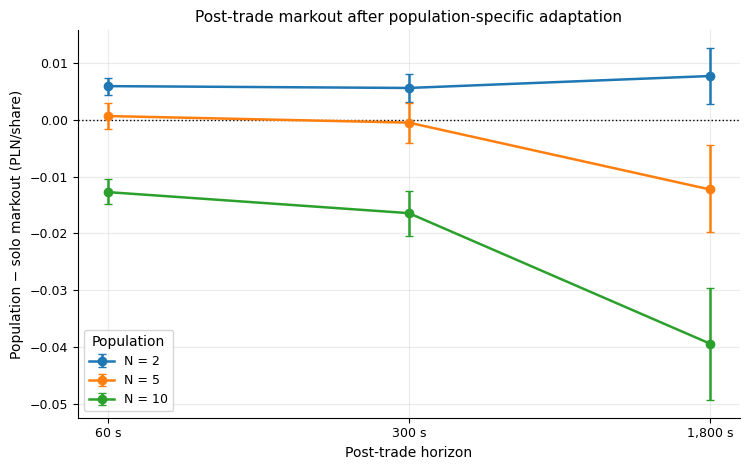

WindowsPath('C:/Users/jaspe/Documents/CLS/Thesis/test_thesis/thesis/figures/simulation_fill_belief/part5_eight_rounds_48x200k_unique_v1_paired_stage4_bank_v1/part5_post_trade_markouts.pdf')

In [ ]:
markout_horizons_s = (60.0, 300.0, 1_800.0)
price_native_to_pln = float(snapshot_kwargs["tick_size"])


def compute_run_markouts(setup_dir, run_id, horizons_s):
    """Return volume-weighted execution markouts for one simulation run."""
    run_suffix = f"{int(run_id):02d}"
    trades = pd.read_parquet(
        setup_dir / f"trades_run{run_suffix}.parquet",
        columns=["t", "sign", "px", "qty"],
    )
    state = pd.read_parquet(
        setup_dir / f"state_run{run_suffix}.parquet",
        columns=["t", "mid", "agent_id"],
    )

    # Every agent observes the same market mid within a run. Agent 0 therefore
    # supplies one non-duplicated path for looking up the future mid.
    mid_path = (
        state.loc[state["agent_id"] == 0, ["t", "mid"]]
        .dropna()
        .sort_values("t")
        .drop_duplicates("t", keep="last")
    )
    mid_times = mid_path["t"].to_numpy(dtype=float)
    mid_values = mid_path["mid"].to_numpy(dtype=float)

    trade_times = trades["t"].to_numpy(dtype=float)
    signs = trades["sign"].to_numpy(dtype=float)
    execution_prices = trades["px"].to_numpy(dtype=float)
    quantities = trades["qty"].to_numpy(dtype=float)
    base_valid = (
        np.isfinite(trade_times)
        & np.isfinite(signs)
        & np.isfinite(execution_prices)
        & np.isfinite(quantities)
        & (quantities > 0)
    )

    rows = []
    for horizon_s in horizons_s:
        future_idx = np.searchsorted(
            mid_times, trade_times + float(horizon_s), side="left"
        )
        valid = base_valid & (future_idx < mid_times.size)
        if not valid.any():
            continue
        future_mid = mid_values[future_idx[valid]]
        markout = (
            signs[valid]
            * (future_mid - execution_prices[valid])
            * price_native_to_pln
        )
        rows.append(
            {
                "run_id": int(run_id),
                "horizon_s": int(horizon_s),
                "post_trade_markout": float(
                    np.average(markout, weights=quantities[valid])
                ),
                "n_trade_rows": int(valid.sum()),
                "executed_volume": float(quantities[valid].sum()),
            }
        )
    return rows


markout_rows = []
for condition in ("solo_adapted", "population_adapted"):
    for n_agents in population_adaptation_counts:
        condition_root = (
            independent_results_dir
            if condition == "solo_adapted"
            else population_results_root / f"N_{n_agents:02d}"
        )
        setup_dir = condition_root / f"setup_{n_agents:02d}"
        for run_id in sorted(evaluation_run_ids_by_n[n_agents]):
            run_rows = compute_run_markouts(
                setup_dir, run_id, markout_horizons_s
            )
            markout_rows.extend(
                {
                    **row,
                    "condition": condition,
                    "n_agents": int(n_agents),
                }
                for row in run_rows
            )

post_trade_markout_runs = pd.DataFrame(markout_rows)
solo_markouts = post_trade_markout_runs.loc[
    post_trade_markout_runs["condition"] == "solo_adapted"
].rename(columns={"post_trade_markout": "solo_markout"})
population_markouts = post_trade_markout_runs.loc[
    post_trade_markout_runs["condition"] == "population_adapted"
].rename(columns={"post_trade_markout": "population_markout"})
paired_markouts = solo_markouts[
    ["n_agents", "run_id", "horizon_s", "solo_markout"]
].merge(
    population_markouts[
        ["n_agents", "run_id", "horizon_s", "population_markout"]
    ],
    on=["n_agents", "run_id", "horizon_s"],
    how="inner",
    validate="one_to_one",
)
paired_markouts["difference"] = (
    paired_markouts["population_markout"] - paired_markouts["solo_markout"]
)

markout_summary_rows = []
for (n_agents, horizon_s), group in paired_markouts.groupby(
    ["n_agents", "horizon_s"]
):
    difference, ci_lo, ci_hi = run_cluster_bootstrap_interval(
        group["difference"].to_numpy(),
        n_bootstrap=bootstrap_samples,
        bootstrap_seed=base_seed + 10_000 + 100 * int(n_agents) + int(horizon_s),
    )
    markout_summary_rows.append(
        {
            "n_agents": int(n_agents),
            "horizon_s": int(horizon_s),
            "solo_markout": float(group["solo_markout"].mean()),
            "population_markout": float(group["population_markout"].mean()),
            "difference": difference,
            "ci_lo": ci_lo,
            "ci_hi": ci_hi,
            "n_pairs": int(len(group)),
        }
    )
markout_summary = pd.DataFrame(markout_summary_rows).sort_values(
    ["n_agents", "horizon_s"]
)
markout_summary.to_csv(
    population_report_cache_dir / "part5_post_trade_markouts.csv",
    index=False,
)

formatted_markouts = markout_summary.assign(
    **{
        "Solo-adapted": markout_summary["solo_markout"].map(lambda x: f"{x:+.5f}"),
        "Population-adapted": markout_summary["population_markout"].map(
            lambda x: f"{x:+.5f}"
        ),
        "Population − solo (95% CI)": markout_summary.apply(
            lambda row: (
                f"{row['difference']:+.5f} "
                f"[{row['ci_lo']:+.5f}, {row['ci_hi']:+.5f}]"
            ),
            axis=1,
        ),
    }
)
print(
    "Markout = fill sign × (future mid − execution price), PLN/share. "
    "Negative population − solo values mean worse post-trade performance."
)
display(
    formatted_markouts[
        [
            "n_agents",
            "horizon_s",
            "Solo-adapted",
            "Population-adapted",
            "Population − solo (95% CI)",
            "n_pairs",
        ]
    ]
)

fig, ax = plt.subplots(figsize=(7.6, 4.8))
x_positions = np.arange(len(markout_horizons_s))
for n_agents, group in markout_summary.groupby("n_agents"):
    ordered = group.set_index("horizon_s").loc[list(map(int, markout_horizons_s))]
    ax.errorbar(
        x_positions,
        ordered["difference"],
        yerr=np.vstack(
            [
                ordered["difference"] - ordered["ci_lo"],
                ordered["ci_hi"] - ordered["difference"],
            ]
        ),
        marker="o",
        capsize=3,
        linewidth=1.8,
        label=f"N = {int(n_agents)}",
    )
ax.axhline(0.0, color="black", linestyle=":", linewidth=1.0)
ax.set_xticks(x_positions, ["60 s", "300 s", "1,800 s"])
ax.set_xlabel("Post-trade horizon")
ax.set_ylabel("Population − solo markout (PLN/share)")
ax.set_title("Post-trade markout after population-specific adaptation")
ax.legend(title="Population")
fig.tight_layout()
markout_figure_path = save_report_figure(
    fig, population_figure_dir / "part5_post_trade_markouts.pdf"
)
display(fig)
plt.close(fig)
markout_figure_path

WindowsPath('C:/Users/jaspe/Documents/CLS/Thesis/test_thesis/thesis/figures/simulation_fill_belief/part5_eight_rounds_48x200k_unique_v1_paired_stage4_bank_v1/part5_population_fill_calibration.pdf')

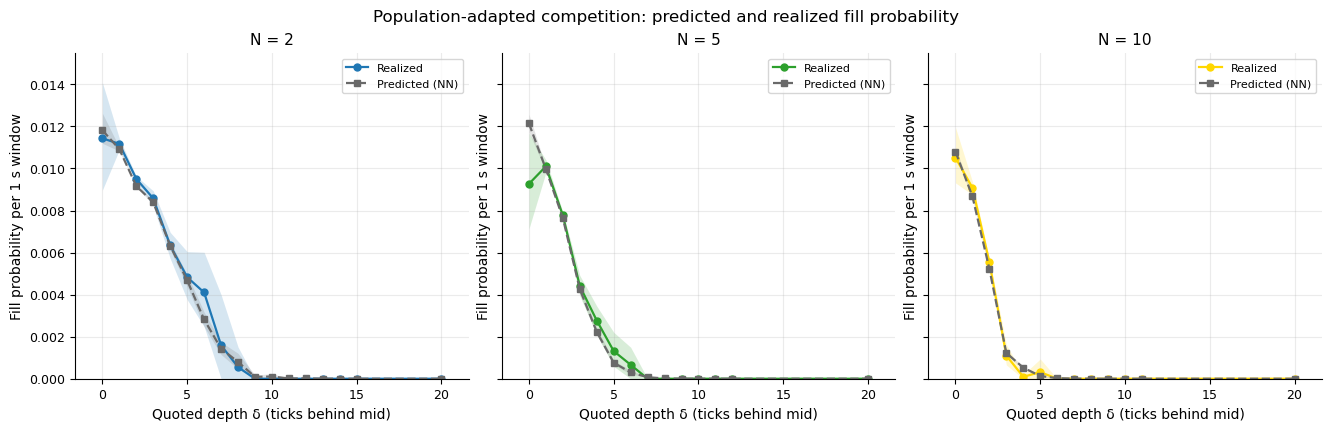

In [20]:
fig = plot_depth_calibration(
    population_calibration,
    title="Population-adapted competition: predicted and realized fill probability",
)
save_report_figure(
    fig, population_figure_dir / "part5_population_fill_calibration.pdf"
)

WindowsPath('C:/Users/jaspe/Documents/CLS/Thesis/test_thesis/thesis/figures/simulation_fill_belief/part5_eight_rounds_48x200k_unique_v1_paired_stage4_bank_v1/part5_population_pnl_distribution.pdf')

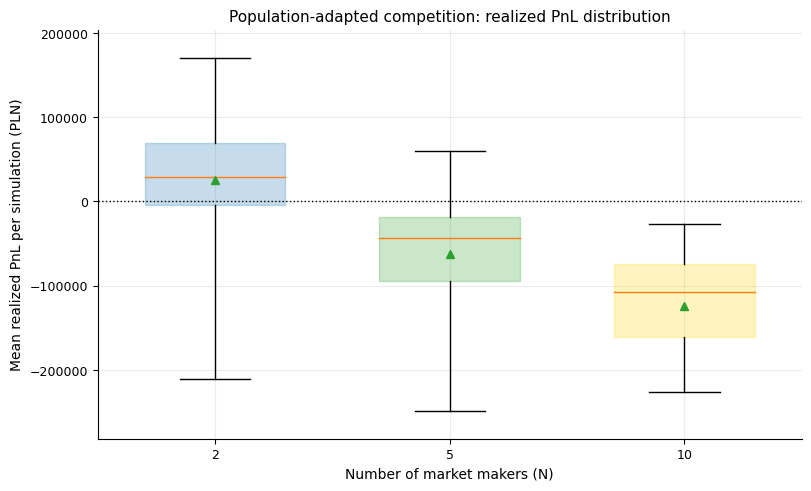

In [21]:
fig = plot_pnl_distributions(
    population_run_metrics,
    title="Population-adapted competition: realized PnL distribution",
)
save_report_figure(
    fig, population_figure_dir / "part5_population_pnl_distribution.pdf"
)

WindowsPath('C:/Users/jaspe/Documents/CLS/Thesis/test_thesis/thesis/figures/simulation_fill_belief/part5_eight_rounds_48x200k_unique_v1_paired_stage4_bank_v1/part5_cross_stage_pnl.pdf')

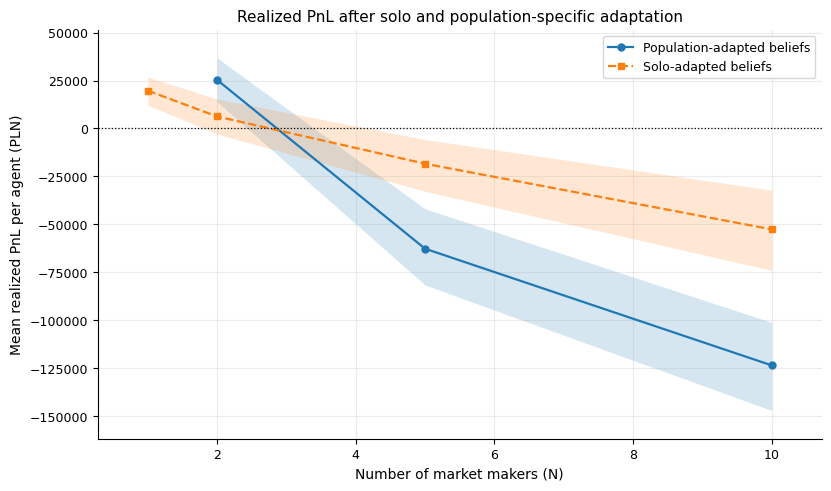

In [22]:
fig = plot_cross_stage_pnl(
    cross_stage_pnl,
    title="Realized PnL after solo and population-specific adaptation",
)
save_report_figure(fig, population_figure_dir / "part5_cross_stage_pnl.pdf")

WindowsPath('C:/Users/jaspe/Documents/CLS/Thesis/test_thesis/thesis/figures/simulation_fill_belief/part5_eight_rounds_48x200k_unique_v1_paired_stage4_bank_v1/part5_population_quoted_depth.pdf')

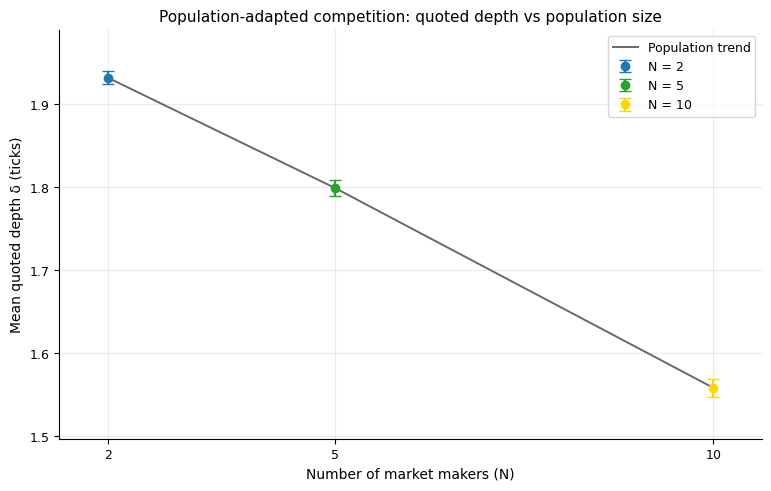

In [23]:
fig = plot_quoted_depth_by_population(
    population_depth,
    title="Population-adapted competition: quoted depth vs population size",
)
save_report_figure(
    fig, population_figure_dir / "part5_population_quoted_depth.pdf"
)

WindowsPath('C:/Users/jaspe/Documents/CLS/Thesis/test_thesis/thesis/figures/simulation_fill_belief/part5_eight_rounds_48x200k_unique_v1_paired_stage4_bank_v1/part5_population_inventory_dispersion.pdf')

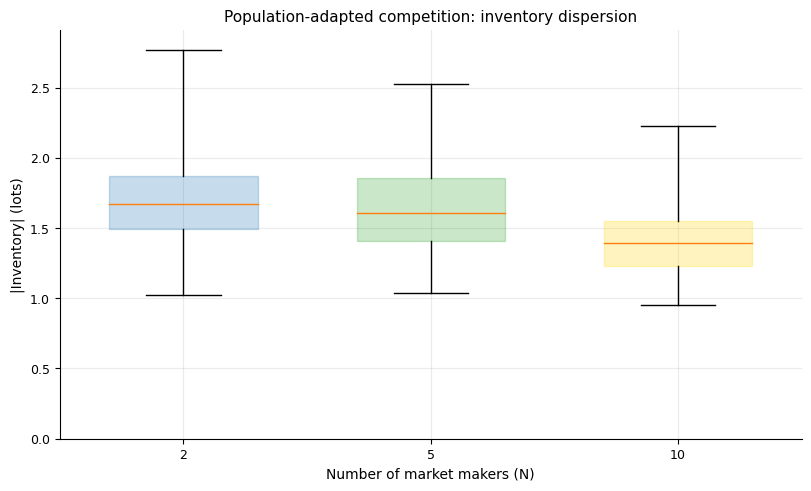

In [24]:
fig = plot_inventory_dispersion(
    population_inventory_dispersion,
    title="Population-adapted competition: inventory dispersion",
    lot_size=order_size,
)
save_report_figure(
    fig, population_figure_dir / "part5_population_inventory_dispersion.pdf"
)

WindowsPath('C:/Users/jaspe/Documents/CLS/Thesis/test_thesis/thesis/figures/simulation_fill_belief/part5_eight_rounds_48x200k_unique_v1_paired_stage4_bank_v1/part5_inventory_depth_three_stages.pdf')

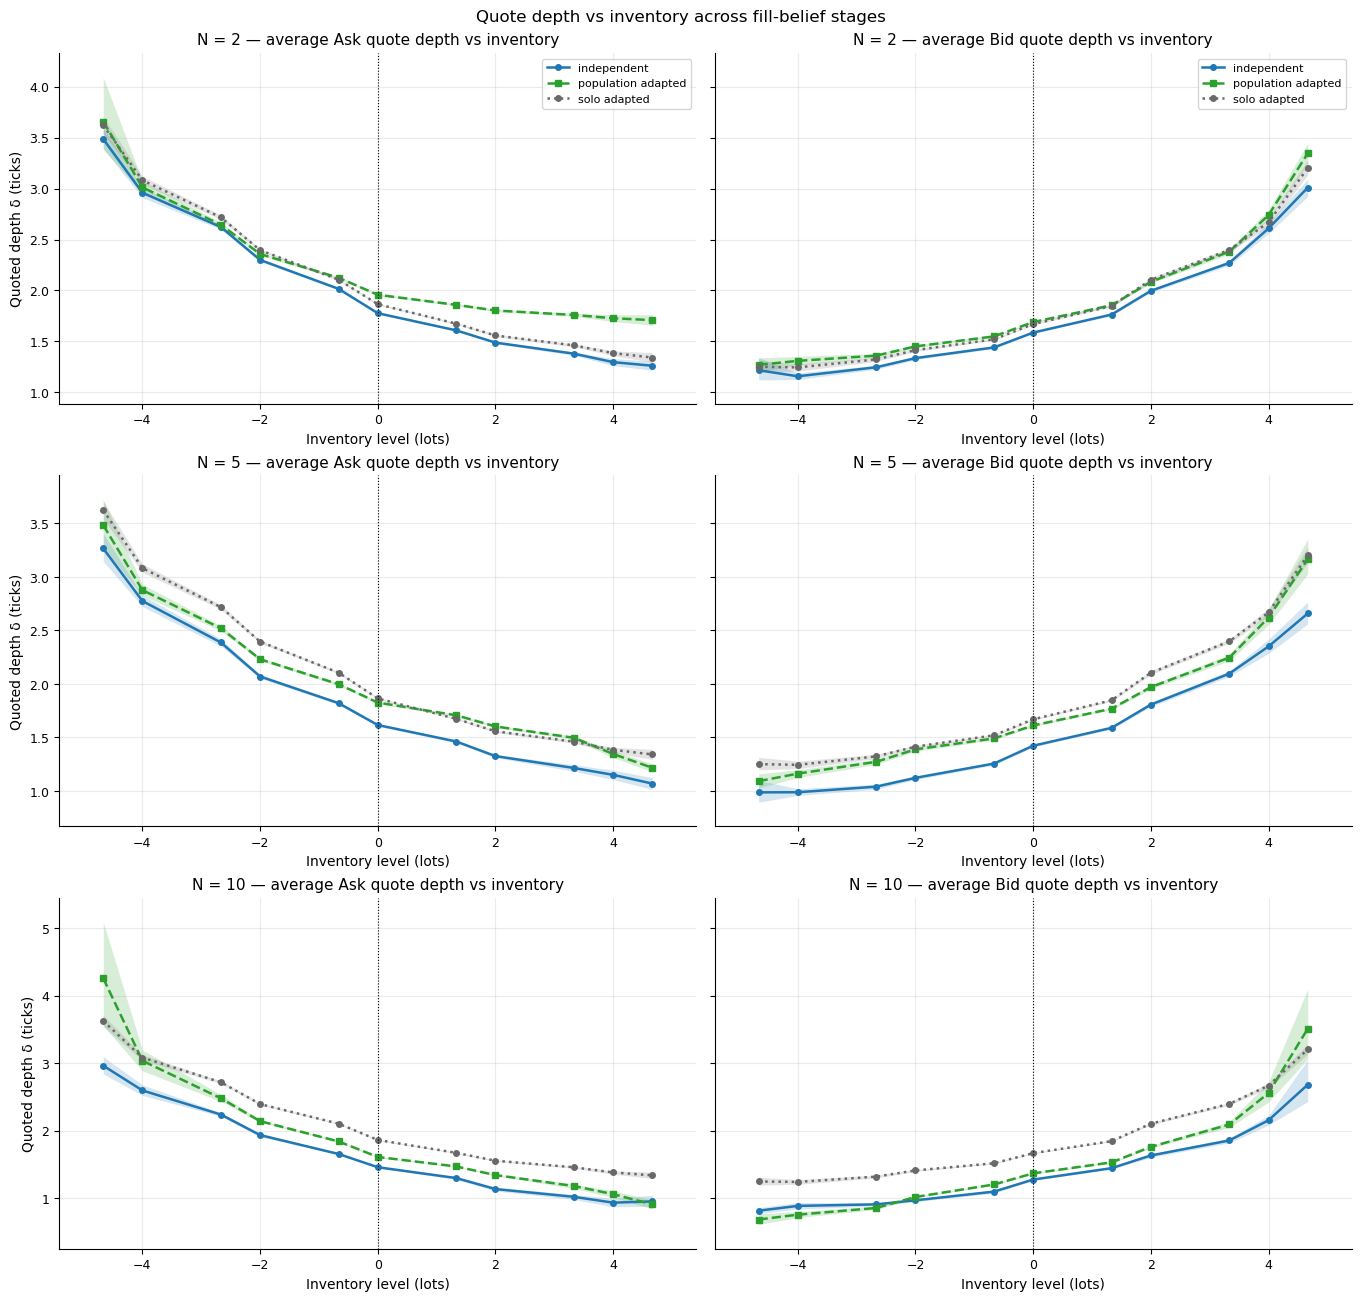

In [25]:
fig = plot_inventory_depth_comparison(
    comparison_inventory_depth,
    title="Quote depth vs inventory across fill-belief stages",
    lot_size=order_size,
)
save_report_figure(
    fig, population_figure_dir / "part5_inventory_depth_three_stages.pdf"
)

WindowsPath('C:/Users/jaspe/Documents/CLS/Thesis/test_thesis/thesis/figures/simulation_fill_belief/part5_eight_rounds_48x200k_unique_v1_paired_stage4_bank_v1/part5_paired_inventory_depth_difference.pdf')

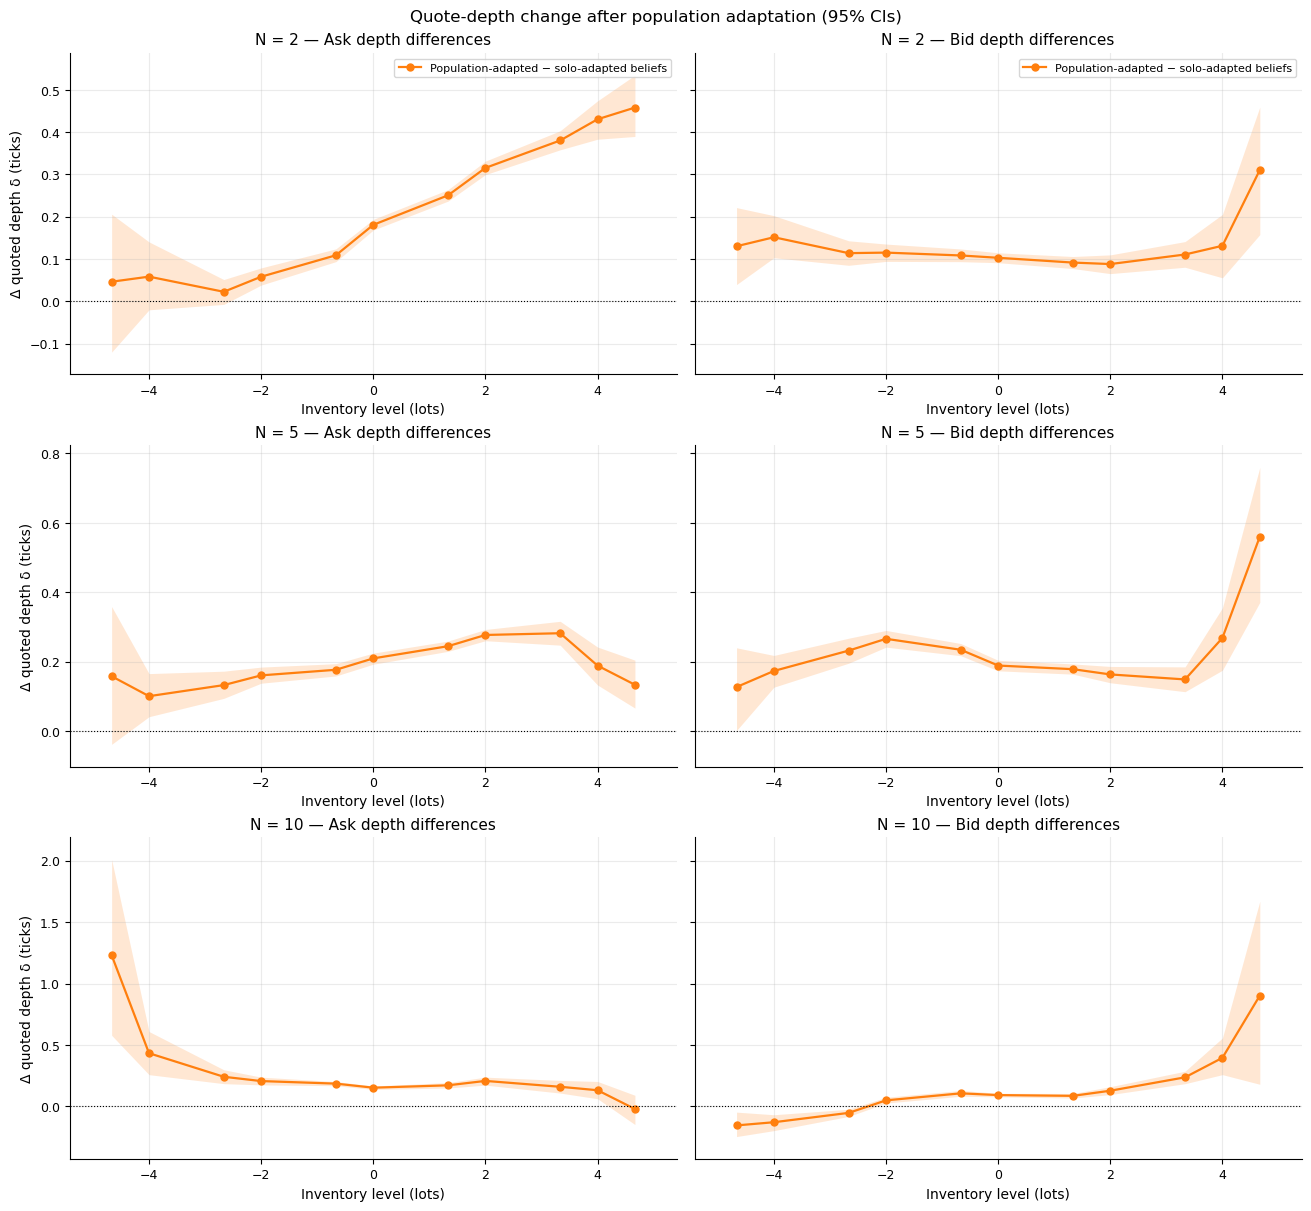

In [26]:
fig = plot_depth_differences(
    paired_depth_differences,
    title="Quote-depth change after population adaptation (95% CIs)",
    lot_size=order_size,
)
save_report_figure(
    fig,
    population_figure_dir / "part5_paired_inventory_depth_difference.pdf",
)

WindowsPath('C:/Users/jaspe/Documents/CLS/Thesis/test_thesis/thesis/figures/simulation_fill_belief/part5_eight_rounds_48x200k_unique_v1_paired_stage4_bank_v1/part5_cross_stage_quoted_depth.pdf')

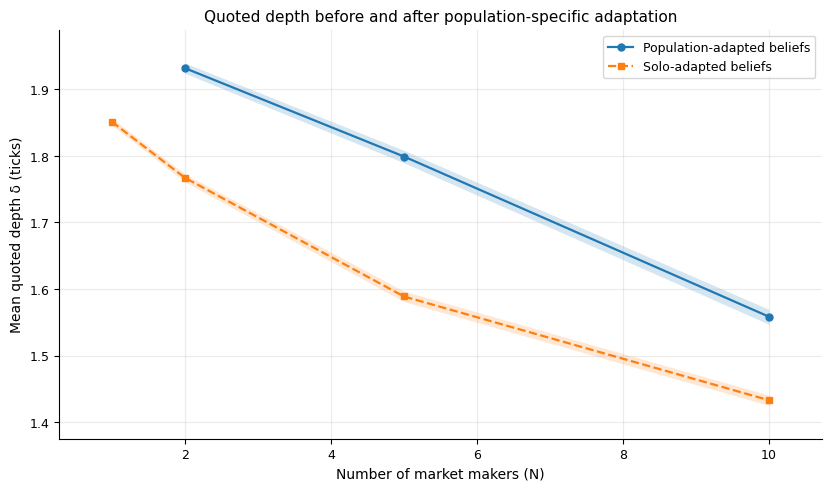

In [27]:
fig = plot_cross_stage_quoted_depth(
    cross_stage_depth,
    title="Quoted depth before and after population-specific adaptation",
)
save_report_figure(
    fig, population_figure_dir / "part5_cross_stage_quoted_depth.pdf"
)